In [1]:
import numpy as np

from ucimlrepo import fetch_ucirepo


def load_glass_data():
    """Load and return the Glass Identification dataset."""
    try:
        glass_data = fetch_ucirepo(id=42)
        X = glass_data.data.features
        y = glass_data.data.targets.values.ravel()

        majority_class = np.bincount(y).argmax()

        y = np.where(y == majority_class, 0, 1)

        return X, y
    except Exception as e:
        print(f"Error loading dataset: {e}")
        raise

X, y = load_glass_data()


Evaluation Results:
Individual fold accuracies: ['0.77', '0.68', '0.86', '0.64', '0.76', '0.81', '0.86', '0.86', '0.62', '0.76']
Mean Accuracy: 0.76 ± 0.09
Accuracy Range: 0.62 - 0.86


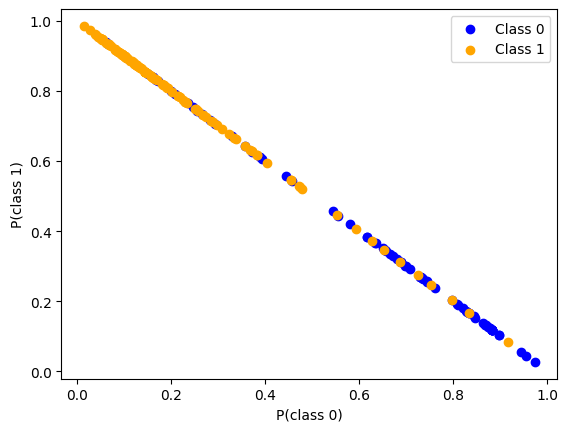

In [2]:
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin

class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold = 0.98):
        self.threshold = threshold
        self.to_drop_ = np.array([], dtype=int)

    def fit(self, X, y = None):
        X = np.asarray(X, dtype=float)
        n_samples, n_features = X.shape

        corr = np.corrcoef(X, rowvar=False)
        upper_mask = np.triu(np.ones((n_features, n_features), bool), k=1)
        high_corr = (np.abs(corr) > self.threshold) & upper_mask
        self.to_drop_ = np.unique(np.where(high_corr)[1])

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)

        if X.shape[1] == 0 or self.to_drop_.size == 0:
            return X.copy()
        
        return np.delete(X, self.to_drop_, axis=1)

svm_pipeline = make_pipeline(
    StandardScaler(),
    VarianceThreshold(threshold=0.1),
    CorrelationFilter(threshold=0.9),
    SVC(probability=True)
)

# Configure cross-validation strategy
cv = StratifiedKFold(n_splits=10, shuffle=True)

# Perform cross-validation
scores = cross_val_score(svm_pipeline, X, y, cv=cv, n_jobs=-1)

# Report results
print("\nEvaluation Results:")
print(f"Individual fold accuracies: {[f'{s:.2f}' for s in scores]}")
print(f"Mean Accuracy: {scores.mean():.2f} ± {scores.std():.2f}")
print(f"Accuracy Range: {scores.min():.2f} - {scores.max():.2f}")

def plot_likelihood_space(Q0, Q1, y):
    """Plot the likelihood space for the two classes."""
    idx0 = (y == 0)
    idx1 = (y == 1)
    plt.scatter(Q0[idx0], Q1[idx0], c='blue', label='Class 0')
    plt.scatter(Q0[idx1], Q1[idx1], c='orange', label='Class 1')
    plt.xlabel('P(class 0)')
    plt.ylabel('P(class 1)')
    plt.legend()
    plt.show()
    plt.close()

svm_pipeline.fit(X, y)
Q = svm_pipeline.predict_proba(X)

Q0, Q1 = Q[:, 0], Q[:, 1]

plot_likelihood_space(Q0, Q1, y)

In [3]:
def mean_distance_to_C0(Q0C):
    """
    Calculate the mean distance of the probabilities of being in class 0
    to 1.0 in the C0 axis.
    """
    return np.mean(np.abs(Q0C - 1.0))

def mean_distance_between_Q0s(Q0C):
    """
    Calculate the mean distance between the probabilities of being in class 0
    for each sample.
    """
    return np.mean(np.abs(Q0C[:, None] - Q0C[None, :]))

Q0C0, Q0C1 = Q0[y == 0], Q0[y == 1]

certainty_C0 = mean_distance_to_C0(Q0C0)
certainty_C1 = 1 - mean_distance_to_C0(Q0C1)
spread_C0 = mean_distance_between_Q0s(Q0C0)
spread_C1 = mean_distance_between_Q0s(Q0C1)

print(f"\nCertainty for Class 0: {certainty_C0:.2f}")
print(f"Certainty for Class 1: {certainty_C1:.2f}")
print(f"Spread for Class 0: {spread_C0:.2f}")
print(f"Spread for Class 1: {spread_C1:.2f}")



Certainty for Class 0: 0.37
Certainty for Class 1: 0.21
Spread for Class 0: 0.29
Spread for Class 1: 0.17



Best C: 0.3415, Best gamma: 0.1032
Optimized Certainty for Class 0: 0.38
Optimized Certainty for Class 1: 0.26
Optimized Spread for Class 0: 0.26
Optimized Spread for Class 1: 0.19


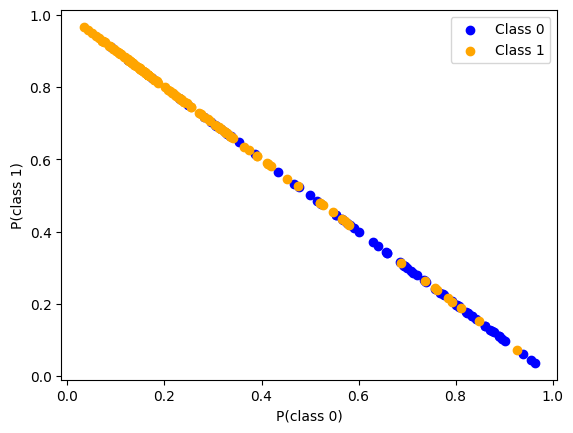


Cross-validated results with optimized parameters:
Individual fold accuracies: ['0.64', '0.64', '0.64', '0.64', '0.76', '0.76', '0.71', '0.67', '0.71', '0.67']
Mean Accuracy: 0.68 ± 0.05
Accuracy Range: 0.64 - 0.76


In [ ]:
from scipy.optimize import dual_annealing

def objective(params, X, y, cv):
    C, gamma = params
    svm_pipeline = make_pipeline(
        StandardScaler(),
        VarianceThreshold(threshold=0.1),
        CorrelationFilter(threshold=0.9),
        SVC(probability=True, C=C, gamma=gamma)
    )
    svm_pipeline.fit(X, y)
    Q = svm_pipeline.predict_proba(X)
    Q0, Q1 = Q[:, 0], Q[:, 1]
    Q0C0, Q0C1 = Q0[y == 0], Q0[y == 1]
    # Certainty: higher is better
    certainty_C0 = mean_distance_to_C0(Q0C0)
    certainty_C1 = 1 - mean_distance_to_C0(Q0C1)
    # Spread: higher is better
    spread_C0 = mean_distance_between_Q0s(Q0C0)
    spread_C1 = mean_distance_between_Q0s(Q0C1)

    # Combine metrics
    # Encourage certainty and spread to be high and balanced between classes
    mean_certainty = (certainty_C0 + certainty_C1) / 2
    mean_spread = (spread_C0 + spread_C1) / 2

    # Penalize imbalance between certainties and between spreads
    certainty_diff = np.abs(certainty_C0 - certainty_C1)
    spread_diff = np.abs(spread_C0 - spread_C1)

    # The score is high when certainties and spreads are both high and balanced
    score = mean_certainty + mean_spread - certainty_diff - spread_diff
    
    # Negative because optimizer minimizes
    return -score

bounds = [(0.1, 5), (0.1, 5)]  # C, gamma

result = dual_annealing(objective, bounds, args=(X, y, cv))
best_C, best_gamma = result.x

print(f"\nBest C: {best_C:.4f}, Best gamma: {best_gamma:.4f}")

# Retrain with best parameters and show metrics
svm_pipeline = make_pipeline(
    StandardScaler(),
    VarianceThreshold(threshold=0.1),
    CorrelationFilter(threshold=0.9),
    SVC(probability=True, C=best_C, gamma=best_gamma)
)
svm_pipeline.fit(X, y)
Q = svm_pipeline.predict_proba(X)
Q0, Q1 = Q[:, 0], Q[:, 1]
Q0C0, Q0C1 = Q0[y == 0], Q0[y == 1]
certainty_C0 = mean_distance_to_C0(Q0C0)
certainty_C1 = 1 - mean_distance_to_C0(Q0C1)
spread_C0 = mean_distance_between_Q0s(Q0C0)
spread_C1 = mean_distance_between_Q0s(Q0C1)

print(f"Optimized Certainty for Class 0: {certainty_C0:.2f}")
print(f"Optimized Certainty for Class 1: {certainty_C1:.2f}")
print(f"Optimized Spread for Class 0: {spread_C0:.2f}")
print(f"Optimized Spread for Class 1: {spread_C1:.2f}")

plot_likelihood_space(Q0, Q1, y)

# Cross-validate the optimized model
optimized_scores = cross_val_score(
    svm_pipeline, X, y, cv=cv, n_jobs=-1
)

print("\nCross-validated results with optimized parameters:")
print(f"Individual fold accuracies: {[f'{s:.2f}' for s in optimized_scores]}")
print(f"Mean Accuracy: {optimized_scores.mean():.2f} ± {optimized_scores.std():.2f}")
print(f"Accuracy Range: {optimized_scores.min():.2f} - {optimized_scores.max():.2f}")

In [9]:
def calculate_sah_score_optimized(points: np.ndarray, segment_a: float, segment_b: float) -> float:
    """
    Calculates the Segment Attractiveness and Homogeneity (SAH) score using NumPy
    for improved performance and conciseness.

    The SAH score ranges from 0 to 1, where 1 represents an ideal
    distribution (all points homogeneously spread within the segment).

    Args:
        points: A 1D NumPy array of points (or convertible to one) representing the
            distribution of interest.
        segment_a: The lower boundary of the segment of interest.
        segment_b: The upper boundary of the segment of interest.

    Returns:
        The SAH score (float between 0 and 1).

    Raises:
        TypeError: If inputs are not of the expected types or convertible.
        ValueError: If segment_a >= segment_b, or if points list is not 1D-like.
    """

    # --- Input Validation ---
    if not isinstance(points, np.ndarray):
        raise TypeError("Input 'points' must be a NumPy array or convertible to one.")
    if not (isinstance(segment_a, (int, float)) and isinstance(segment_b, (int, float))):
        raise TypeError("Segment boundaries 'segment_a' and 'segment_b' must be numbers.")

    if segment_a >= segment_b:
        raise ValueError("Segment start 'segment_a' must be strictly less than segment end 'segment_b'. The segment length L must be > 0.")

    if not points.any(): # Handle empty list explicitly
        points_arr = np.array([], dtype=float)
    else:
        try:
            # Attempt to convert; this will also catch non-numeric list contents
            points_arr = np.array(points, dtype=float)
        except (TypeError, ValueError) as e: # Catch errors during conversion
            raise TypeError(f"All elements in 'points' must be numbers. Error during conversion: {e}")

        # Ensure it's a 1D array (e.g. points wasn't a list of lists)
        if points_arr.ndim != 1:
            raise ValueError("Input 'points' must be a 1D list of numbers (or convertible to a 1D array).")

    n = len(points_arr)
    segment_length_L = segment_b - segment_a # L > 0 is guaranteed

    # --- I. Segment Attractiveness Weight Function (w(x)) ---
    if n == 0:
        point_weights = np.array([], dtype=float)
    else:
        # Calculate distance dS(x) for each point x from the segment [a,b]
        # dS(x) = 0 if a <= x <= b
        # dS(x) = a - x if x < a
        # dS(x) = x - b if x > b
        conditions = [
            points_arr < segment_a,  # Condition for points left of segment
            points_arr > segment_b   # Condition for points right of segment
        ]
        choices = [
            segment_a - points_arr,  # Value if points_arr < segment_a
            points_arr - segment_b   # Value if points_arr > segment_b
        ]
        d_S_x = np.select(conditions, choices, default=0.0)

        # Calculate weights w(xi) = exp( -2 * (dS(xi))^2 / L^2 )
        point_weights = np.exp(-2 * (d_S_x ** 2) / (segment_length_L ** 2))

    # --- II. Calculating the SAH Score ---

    # 1. Calculate Mean Attractiveness (MA)
    if n == 0:
        mean_attractiveness_MA = 0.0
    else:
        mean_attractiveness_MA = np.sum(point_weights) / n

    # 2. Calculate Weighted Homogeneity (HW)
    weighted_homogeneity_HW = 1.0  # Default for n <= 1

    if n > 1:
        # Sort points to calculate nearest neighbor distances efficiently.
        # Weights must be sorted according to the points.
        sorted_indices = np.argsort(points_arr)
        _sorted_points = points_arr[sorted_indices]
        _sorted_weights = point_weights[sorted_indices] # Weights corresponding to sorted points
        
        W_sum = np.sum(_sorted_weights)

        if np.isclose(W_sum, 0): # All points have negligible weight
            weighted_homogeneity_HW = 1.0
        else:
            # Calculate nearest neighbor distances (nn_dists_sorted) for the sorted points
            nn_dists_sorted = np.zeros(n)
            deltas = np.diff(_sorted_points) # Distances between adjacent sorted points (length n-1)

            if n == 2: # Only one delta
                nn_dists_sorted[0] = deltas[0]
                nn_dists_sorted[1] = deltas[0]
            else: # n > 2 (deltas has at least 2 elements)
                nn_dists_sorted[0] = deltas[0] # Nearest for first point is the next one
                nn_dists_sorted[-1] = deltas[-1] # Nearest for last point is the previous one
                # For intermediate points, min of distance to previous and distance to next
                nn_dists_sorted[1:-1] = np.minimum(deltas[:-1], deltas[1:])
            
            # d. Calculate the weighted mean of nearest neighbor distances (mu_d)
            mu_d = np.sum(nn_dists_sorted * _sorted_weights) / W_sum

            # e. Calculate the weighted variance of nearest neighbor distances (sigma_d_sq)
            variance_terms = ((nn_dists_sorted - mu_d) ** 2) * _sorted_weights
            sigma_d_sq = np.sum(variance_terms) / W_sum
            sigma_d_sq = np.maximum(0, sigma_d_sq) # Ensure non-negativity due to float precision

            # f. Calculate the weighted coefficient of variation (CV_d)
            if np.isclose(mu_d, 0): # Implies all relevant points are co-located (d_i=0 for them)
                cv_d = 0.0
            else:
                cv_d = np.sqrt(sigma_d_sq) / mu_d
            
            # g. The homogeneity score HW
            weighted_homogeneity_HW = 1.0 / (1.0 + cv_d)
    
    # 3. Final SAH Score
    sah_score = mean_attractiveness_MA * weighted_homogeneity_HW

    return sah_score

Q = make_pipeline(
    StandardScaler(),
    VarianceThreshold(threshold=0.1),
    CorrelationFilter(threshold=0.9),
    SVC(probability=True)
).fit(X, y).predict_proba(X)

Q0, _ = Q[:, 0], Q[:, 1]
Q0C0, Q0C1 = Q0[y == 0], Q0[y == 1]

sah_score_C0 = calculate_sah_score_optimized(Q0C0, 0.5, 1.0)
sah_score_C1 = calculate_sah_score_optimized(Q0C1, 0.0, 0.5)

print(f"SAH Score for Class 0: {sah_score_C0:.4f}")
print(f"SAH Score for Class 1: {sah_score_C1:.4f}")

SAH Score for Class 0: 0.4260
SAH Score for Class 1: 0.2951


In [ ]:
def sah_objective(params, X, y):
    C, gamma = params
    pipeline = make_pipeline(
        StandardScaler(),
        VarianceThreshold(threshold=0.1),
        CorrelationFilter(threshold=0.9),
        SVC(probability=True, C=C, gamma=gamma)
    )
    pipeline.fit(X, y)
    Q = pipeline.predict_proba(X)
    Q0 = Q[:, 0]
    Q0C0, Q0C1 = Q0[y == 0], Q0[y == 1]
    sah0 = calculate_sah_score_optimized(Q0C0, 0.5, 1.0)
    sah1 = calculate_sah_score_optimized(Q0C1, 0.0, 0.5)
    # Objective: maximize mean SAH, minimize difference
    mean_sah = (sah0 + sah1) / 2
    sah_diff = np.abs(sah0 - sah1)
    score = mean_sah - sah_diff
    return -score  # minimize

sah_bounds = [(0.1, 5), (0.1, 5)]  # C, gamma

sah_result = dual_annealing(sah_objective, sah_bounds, args=(X, y))
sah_C, sah_gamma = sah_result.x

print(f"Best C: {sah_C:.4f}, Best gamma: {sah_gamma:.4f}")

Best C: 0.4686, Best gamma: 0.1770
Optimized SAH Score for Class 0: 0.3847
Optimized SAH Score for Class 1: 0.3461
Difference: 0.0386

Cross-validated results with SAH-optimized parameters:
Individual fold accuracies: ['0.73', '0.73', '0.73', '0.77', '0.81', '0.86', '0.67', '0.76', '0.71', '0.81']
Mean Accuracy: 0.76 ± 0.05
Accuracy Range: 0.67 - 0.86


Optimized SAH Score for Class 0: 0.3887
Optimized SAH Score for Class 1: 0.3443
Difference: 0.0443


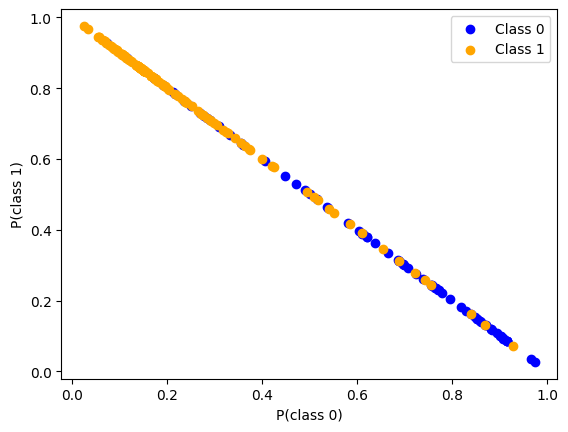


Cross-validated results with SAH-optimized parameters:
Individual fold accuracies: ['0.77', '0.73', '0.59', '0.73', '0.81', '0.86', '0.86', '0.76', '0.81', '0.76']
Mean Accuracy: 0.77 ± 0.07
Accuracy Range: 0.59 - 0.86


In [11]:
# Evaluate final sah scores
pipeline = make_pipeline(
    StandardScaler(),
    VarianceThreshold(threshold=0.1),
    CorrelationFilter(threshold=0.9),
    SVC(probability=True, C=sah_C, gamma=sah_gamma)
)
pipeline.fit(X, y)
Q = pipeline.predict_proba(X)
Q0, Q1 = Q[:, 0], Q[:, 1]
Q0C0, Q0C1 = Q0[y == 0], Q0[y == 1]
sah0 = calculate_sah_score_optimized(Q0C0, 0.5, 1.0)
sah1 = calculate_sah_score_optimized(Q0C1, 0.0, 0.5)
print(f"Optimized SAH Score for Class 0: {sah0:.4f}")
print(f"Optimized SAH Score for Class 1: {sah1:.4f}")
print(f"Difference: {abs(sah0-sah1):.4f}")

plot_likelihood_space(Q0, Q1, y)

sah_cv = StratifiedKFold(n_splits=10, shuffle=True)
sah_scores = cross_val_score(
    make_pipeline(
        StandardScaler(),
        VarianceThreshold(threshold=0.1),
        CorrelationFilter(threshold=0.9),
        SVC(probability=True, C=sah_C, gamma=sah_gamma)
    ),
    X, y, cv=sah_cv, n_jobs=-1
)

print("\nCross-validated results with SAH-optimized parameters:")
print(f"Individual fold accuracies: {[f'{s:.2f}' for s in sah_scores]}")
print(f"Mean Accuracy: {sah_scores.mean():.2f} ± {sah_scores.std():.2f}")
print(f"Accuracy Range: {sah_scores.min():.2f} - {sah_scores.max():.2f}")